# Demystifying Simple Linear Regression - Building Everything From Scratch

## Overview

I downloaded a dataset from *kaggle* entitled *Salary_Data* of shape (6704, 6). It consists of age, gender, education level, job title, years of experience and salary columns, from which, for the purpose of building a simple linear regression model (one input feature), I selected years of experience as the independent variable and salary as the target.

I used NumPy, Pandas, and Matplotlib to handle calculations, data handling, and plotting respectively.

*models.py* is where I wrote the functionality of the model (from scratch) and other reusable tools. As I progress forward, models.py will be the monolithic file where the core of other models-like that of a multi linear one-will be written (unless ofc I change my mind/it gets too intricate).

Here is the [link](https://www.kaggle.com/datasets/mohithsairamreddy/salary-data) to the dataset.

## Imports

In [303]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import importlib

Jupyter Notebook stores the *models* module once in memory and reuse that every time any cell is executed. With *importlib* we force import the module no matter what, ensuring any changes in the module are included here accordingly.

In [304]:
import models

importlib.reload(models)

from models import *

## Data Preparation, Cleaning, and Preprocessing

### Preparation and Cleaning

In [305]:
load_df = pd.read_csv("./datasets/Salary_Data.csv")

df = pd.DataFrame(load_df)

print("Original dataset size: ", len(df))

dropped_rows = df[df[["Years of Experience", "Salary"]].isnull().any(axis=1)]
df = df.dropna(subset=["Years of Experience", "Salary"])

print("Number of dropped rows: ", len(dropped_rows))

Original dataset size:  6704
Number of dropped rows:  5


Its a good practice to not just throw off unwanted rows (even if every data in them are null/nan). Their existence by itself gives some insights.

In [310]:
display(df)
display(dropped_rows)

,Age,Gender,Education Level,Job Title,Years of Experience,Salary
0,32.0,Male,Bachelor's,Software Engineer,5.0,90000.0
1,28.0,Female,Master's,Data Analyst,3.0,65000.0
2,45.0,Male,PhD,Senior Manager,15.0,150000.0
3,36.0,Female,Bachelor's,Sales Associate,7.0,60000.0
4,52.0,Male,Master's,Director,20.0,200000.0
...,...,...,...,...,...,...
6699,49.0,Female,PhD,Director of Marketing,20.0,200000.0
6700,32.0,Male,High School,Sales Associate,3.0,50000.0
6701,30.0,Female,Bachelor's Degree,Financial Manager,4.0,55000.0
6702,46.0,Male,Master's Degree,Marketing Manager,14.0,140000.0


,Age,Gender,Education Level,Job Title,Years of Experience,Salary
172,NaN,NaN,NaN,NaN,NaN,NaN
260,NaN,NaN,NaN,NaN,NaN,NaN
3136,31.0,Male,Master's Degree,Full Stack Engineer,8.0,NaN
5247,26.0,Female,Bachelor's Degree,Social M,NaN,NaN
6455,36.0,Male,Bachelor's Degree,Sales Director,6.0,NaN


*np.random.permutation* takes an integer *n* as input and generates a list of integers starting from 0 up to n-1, but in random order.

In [311]:
perm = np.random.permutation(len(df))

In [312]:
X = df["Years of Experience"].values[perm]
y = df["Salary"].values[perm]

Treating the values in *perm* as indices, we can use it alongside a Pandas Series/DataFrame-*df["salary"].values[perm]*-to get a Series/DataFrame by the order of indices provided in the *perm* list.

Even though our original dataframe seems random, it's a good habit to randomize before use.

### Preprocessing

In [313]:
stat_kit = StatKit()
model_kit = ModelKit()

In [314]:
X_train, X_test = model_kit.split_data(X, 0.8)
y_train, y_test = model_kit.split_data(y, 0.8)

X_train_scaled = stat_kit.standardize(X_train)[0]
X_test_scaled, X_test_mean, X_test_std = stat_kit.standardize(X_test)

It is unnecessary to scale the target data, as it is "the target" because it's not used in developing the core model but just to best fit the hyperplane.

## Model Training, Prediction and Evaluation

### Training

In [320]:
simple_model = SLR(np.array([X_train_scaled, y_train]))

print("model parameters m and b: ", simple_model.get_params())

model parameters m and b:  (np.float64(42366.23063422259), np.float64(115385.9373017354))


### Prediction

In [316]:
y_pred = simple_model.predict(X_test_scaled)

### Evaluation

In [317]:
model_kit.MAE(y_pred, y_test)

np.float64(24458.9602686054)

## Plotting

Reversing the scaling effect for the sake of plotting.

In [318]:
X_test_descaled = X_test_scaled * X_test_std + X_test_mean

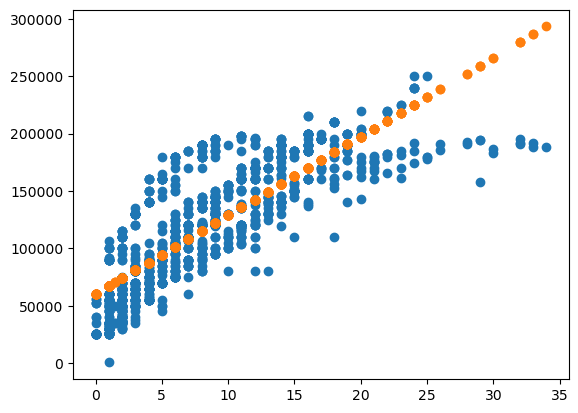

In [319]:
plt.scatter(X_test_descaled, y_test)
plt.scatter(X_test_descaled, y_pred)